# Day 113 — Week 5 Mini-Project: Full Customer Segmentation Pipeline
**Month 6 | Week 5 | Mini-Project | 100 Points + 15★ Bonus**

---

## What This Mini-Project Tests

This is your integration deliverable for Week 5. You will build a **complete, client-ready segmentation pipeline** from raw data to business recommendation — using every skill from Days 110–112 in a single coherent workflow.

| Skill | Days | Applied Here |
|-------|------|-------------|
| K-Means Clustering | Day 110 | Primary segmentation engine |
| Hierarchical + DBSCAN | Day 111 | Cluster validation + noise detection |
| PCA | Day 112 | Dimensionality reduction + visualisation |

**No new syntax is introduced today.** Every function you need has been used before.

---

## The Business Brief

ShopEase's Head of Marketing sends you this brief:

> *"We've been doing ad-hoc targeting for 3 years. I want a data-driven answer to: who are our customers? Give me 3–4 distinct segments with names, characteristics, and one specific action I can take for each. I need this in a format I can present to the board next Friday."*

Your job: build the full pipeline, generate the segments, and produce the NRA business report.

---

## Scoring Overview

| Part | Topic | Points |
|------|-------|--------|
| A | Data Preparation | 20 |
| B | PCA Pipeline | 25 |
| C | K-Means Segmentation | 25 |
| D | Cluster Validation | 15 |
| E | Business Report (NRA) | 15 |
| ★ | Bonus — Dendrogram on PCA data | 15 |
| **Total** | | **100 + 15★** |

---

## File Rules
1. Do **not** modify the Raw Data section
2. Run all cells **top to bottom** — outputs must be visible before submission
3. NRA insights must use **computed numbers from your outputs**, not estimates
4. `savefig()` before `plt.show()` — same rule as always


---
## Section 1 — Raw Data

> **Do not modify this section.** All work starts from `df_raw` copied in Section 2.

In [1]:
# ── RAW DATA — DO NOT MODIFY ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N = 300

# Generate ShopEase customer dataset (6 behavioural features)
df_raw = pd.DataFrame({
    'customer_id': [f'CUST{str(i).zfill(4)}' for i in range(1, N+1)],
    
    # Segment A: High spenders, frequent buyers, low returns
    # Segment B: Mid-spend, infrequent, high browsing
    # Segment C: Low-spend, high-return, low satisfaction
    # Noise: scattered outliers
    'annual_spend':       np.concatenate([
                              np.random.normal(28000, 4000, 100),   # A
                              np.random.normal(12000, 2500, 100),   # B
                              np.random.normal(4500,  1200, 80),    # C
                              np.random.uniform(1000, 40000, 20)    # noise
                          ]),
    'purchase_frequency': np.concatenate([
                              np.random.normal(22, 4,  100),
                              np.random.normal(9,  2,  100),
                              np.random.normal(4,  1.5, 80),
                              np.random.uniform(1, 30,  20)
                          ]),
    'avg_order_value':    np.concatenate([
                              np.random.normal(1400, 200, 100),
                              np.random.normal(700,  150, 100),
                              np.random.normal(310,  80,  80),
                              np.random.uniform(100, 2000, 20)
                          ]),
    'return_rate':        np.concatenate([
                              np.random.normal(0.05, 0.02, 100).clip(0, 1),
                              np.random.normal(0.12, 0.04, 100).clip(0, 1),
                              np.random.normal(0.32, 0.08, 80).clip(0, 1),
                              np.random.uniform(0, 0.5, 20)
                          ]),
    'site_visits_monthly':np.concatenate([
                              np.random.normal(18, 4,  100),
                              np.random.normal(28, 6,  100),
                              np.random.normal(10, 3,  80),
                              np.random.uniform(1, 40,  20)
                          ]),
    'satisfaction_score': np.concatenate([
                              np.random.normal(8.4, 0.6, 100).clip(1, 10),
                              np.random.normal(6.8, 0.8, 100).clip(1, 10),
                              np.random.normal(4.5, 1.0, 80).clip(1, 10),
                              np.random.uniform(1, 10, 20)
                          ])
})

# Clip negative values
df_raw['annual_spend']       = df_raw['annual_spend'].clip(lower=500)
df_raw['purchase_frequency'] = df_raw['purchase_frequency'].clip(lower=1)
df_raw['avg_order_value']    = df_raw['avg_order_value'].clip(lower=50)

print("Raw Data loaded successfully.")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst 5 rows:")
df_raw.head()


Raw Data loaded successfully.
Shape: (300, 7)
Columns: ['customer_id', 'annual_spend', 'purchase_frequency', 'avg_order_value', 'return_rate', 'site_visits_monthly', 'satisfaction_score']

First 5 rows:


,customer_id,annual_spend,purchase_frequency,avg_order_value,return_rate,site_visits_monthly,satisfaction_score
0,CUST0001,29986.856612,19.642541,1414.313247,0.061813,21.673266,8.327431
1,CUST0002,27446.942795,25.398408,1304.468511,0.072174,11.717998,8.651719
2,CUST0003,30590.754152,23.428062,1495.795965,0.066410,14.041487,7.867505
3,CUST0004,34092.119426,19.228362,1466.732421,0.060145,21.763085,8.137525
4,CUST0005,27063.386501,25.598400,1607.507989,0.071333,14.070050,8.833429


---
## Section 2 — Practice Guide

Work through Parts A → E in order. Each part builds on the previous one.  
The ★ Bonus (Part F) is independent — attempt it after Part E.

---

### Part A — Data Preparation (20 points)

**Task A1 (8 pts):** Copy `df_raw` to `df` (do not modify raw). Then:
- Select only the 6 numeric feature columns into `features` (list)
- Create `X_raw = df[features].values`
- Print `df.describe()` — check for any negative values and confirm ranges

**Task A2 (7 pts):** Scale the data.
- Import `StandardScaler` from sklearn.preprocessing
- Fit and transform `X_raw` → store as `X_scaled`
- Print the mean and std of `X_scaled` — confirm mean ≈ 0, std ≈ 1

**Task A3 (5 pts):** Write a 2-sentence markdown insight:
- State which feature has the widest original range (from A1 describe output)
- Explain in one sentence why that makes scaling essential before PCA or clustering


In [2]:
# =============================================================================
# PART A – DATA PREPARATION
# TASK A1 – Copy df_raw, select 6 numeric features, print describe()
# Goal: Create a working copy and examine feature ranges.
# Method: .copy() to avoid modifying raw; select all columns except customer_id.
# =============================================================================

df = df_raw.copy()   # never modify raw data directly

features = ['annual_spend', 'purchase_frequency', 'avg_order_value',
            'return_rate', 'site_visits_monthly', 'satisfaction_score']

X_raw = df[features].values

print("A1 – Feature statistics (original scale):")
print(df[features].describe().round(2))

A1 – Feature statistics (original scale):
       annual_spend  purchase_frequency  avg_order_value  return_rate  \
count        300.00              300.00           300.00       300.00   
mean       15684.45               12.58           852.46         0.16   
std        10179.97                8.31           473.93         0.13   
min          610.48                1.00           188.74         0.00   
25%         5804.97                5.29           423.81         0.06   
50%        12737.57                9.75           758.45         0.12   
75%        26084.54               20.73          1306.14         0.24   
max        38486.43               30.76          1914.67         0.52   

       site_visits_monthly  satisfaction_score  
count               300.00              300.00  
mean                 19.32                6.71  
std                   8.39                1.75  
min                   1.20                1.64  
25%                  12.57                5.43  
50%   

In [3]:
# =============================================================================
# TASK A2 – Scale features with StandardScaler
# Goal: Bring all features to mean=0, std=1 for PCA and clustering.
# Method: fit_transform on X_raw, then verify means and stds.
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("A2 – Scaled feature stats (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.agg(['mean', 'std']).round(6))

A2 – Scaled feature stats (mean ≈ 0, std ≈ 1):
      annual_spend  purchase_frequency  avg_order_value  return_rate  \
mean     -0.000000            0.000000         0.000000     0.000000   
std       1.001671            1.001671         1.001671     1.001671   

      site_visits_monthly  satisfaction_score  
mean             0.000000           -0.000000  
std              1.001671            1.001671  


### A3 – Why scaling is mandatory

From the `describe()` output above, `annual_spend` has the widest range (₹610.48 – ₹38,486.43), while `return_rate` ranges from 0.00 to 0.52. Without scaling, Euclidean distance would be dominated by spend, and PCA would align its first component almost entirely with spend. Scaling ensures every behavioural feature contributes equally to the segmentation.

---

### Part B — PCA Pipeline (25 points)

**Task B1 (8 pts):** Run full PCA on all 6 components.
- Import `PCA` from sklearn.decomposition
- Fit `PCA(n_components=6, random_state=42)` on `X_scaled` → store as `pca_full`
- Print the explained variance ratio for each component (round to 4 decimal places)
- Print the cumulative explained variance

**Task B2 (10 pts):** Build the Scree Plot.
- Bar chart: explained variance ratio per component (blue bars)
- Line chart (on same axes): cumulative variance
- Add a horizontal dashed red line at 0.80 (80% threshold)
- Mark with an annotation the point where cumulative variance first crosses 80%
- Title must state the insight (not describe the data)
- Save as `scree_plot.png`

**Task B3 (7 pts):** Reduce to 2D for visualisation.
- Fit `PCA(n_components=2, random_state=42)` on `X_scaled` → store as `pca2`
- Transform `X_scaled` → store as `X_2d` (shape should be 300×2)
- Print the % variance explained by PC1 and PC2 (from `pca2.explained_variance_ratio_`)
- Print total % variance retained in 2D


In [4]:
# =============================================================================
# PART B – PCA PIPELINE
# TASK B1 – Fit PCA on all 6 components, print explained variance ratios
# Goal: Understand how much variance each principal component captures.
# Method: PCA(n_components=6, random_state=42) on X_scaled.
# =============================================================================

pca_full = PCA(n_components=6, random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

print("B1 – Explained variance ratio (6 components):")
for i in range(6):
    print(f"  PC{i+1}: {evr[i]:.4f}  |  Cumulative: {cumulative[i]:.4f}")

B1 – Explained variance ratio (6 components):
  PC1: 0.6632  |  Cumulative: 0.6632
  PC2: 0.1810  |  Cumulative: 0.8442
  PC3: 0.0536  |  Cumulative: 0.8979
  PC4: 0.0440  |  Cumulative: 0.9418
  PC5: 0.0366  |  Cumulative: 0.9784
  PC6: 0.0216  |  Cumulative: 1.0000


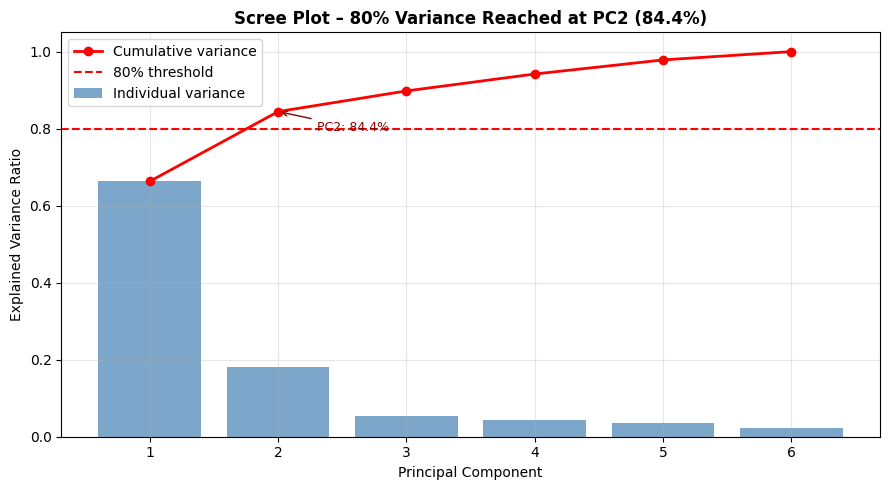

scree_plot.png saved ✅


In [5]:
# =============================================================================
# TASK B2 – Scree plot with 80% threshold and annotation
# Goal: Visualise the elbow and where cumulative variance crosses 80%.
# Method: Bar chart + line plot, horizontal dashed line at 0.80, mark crossing.
# =============================================================================

plt.figure(figsize=(9, 5))
components = range(1, 7)

# Bars for individual variance
plt.bar(components, evr, alpha=0.7, color='steelblue', label='Individual variance')

# Line for cumulative variance
plt.plot(components, cumulative, 'ro-', linewidth=2, markersize=6, label='Cumulative variance')

# 80% threshold line
plt.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')

# Find first PC where cumulative >= 80%
cross_pc = np.argmax(cumulative >= 0.80) + 1
plt.annotate(f'PC{cross_pc}: {cumulative[cross_pc-1]*100:.1f}%',
             xy=(cross_pc, cumulative[cross_pc-1]),
             xytext=(cross_pc+0.3, cumulative[cross_pc-1]-0.05),
             arrowprops=dict(arrowstyle='->', color='darkred'),
             fontsize=9, color='darkred')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title(f'Scree Plot – 80% Variance Reached at PC{cross_pc} ({cumulative[cross_pc-1]*100:.1f}%)', fontweight='bold')
plt.xticks(components)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("scree_plot.png saved ✅")

In [6]:
# =============================================================================
# TASK B3 – PCA with 2 components
# Goal: Create a 2D projection for scatter plots and clustering.
# Method: PCA(n_components=2, random_state=42).fit_transform(X_scaled).
# =============================================================================

pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

pc1_var = pca2.explained_variance_ratio_[0] * 100
pc2_var = pca2.explained_variance_ratio_[1] * 100
total_var = pc1_var + pc2_var

print("B3 – PCA 2D reduction:")
print(f"  PC1 explains {pc1_var:.2f}% of variance")
print(f"  PC2 explains {pc2_var:.2f}% of variance")
print(f"  Total retained in 2D: {total_var:.2f}%")
print(f"  X_2d shape: {X_2d.shape}")

B3 – PCA 2D reduction:
  PC1 explains 66.32% of variance
  PC2 explains 18.10% of variance
  Total retained in 2D: 84.42%
  X_2d shape: (300, 2)


---

### Part C — K-Means Segmentation (25 points)

**Task C1 (8 pts):** Find the optimal number of clusters using the Elbow Method.
- Test `k` from 2 to 8 on `X_2d` (the PCA-reduced data)
- Store inertia values and plot the elbow curve
- Annotate the elbow point on the chart
- Title must state the chosen k and why
- Save as `elbow_curve.png`

**Task C2 (10 pts):** Fit the final K-Means model.
- Fit `KMeans(n_clusters=<your_k>, random_state=42, n_init=10)` on `X_2d`
- Store cluster labels in `df['cluster']`
- Print cluster sizes (value_counts)
- Build a 2D scatter plot:
  - X axis: PC1 (with % variance from B3)
  - Y axis: PC2 (with % variance from B3)
  - Color by cluster label
  - Add cluster centroids as black ✕ markers
  - Save as `kmeans_pca_scatter.png`

**Task C3 (7 pts):** Build a cluster profile table.
- Group `df` by `cluster`, compute mean of all 6 features
- Round to 2 decimal places
- Print the full table
- In a markdown cell below, name each cluster (e.g. "Premium Loyalists") based on the profile numbers


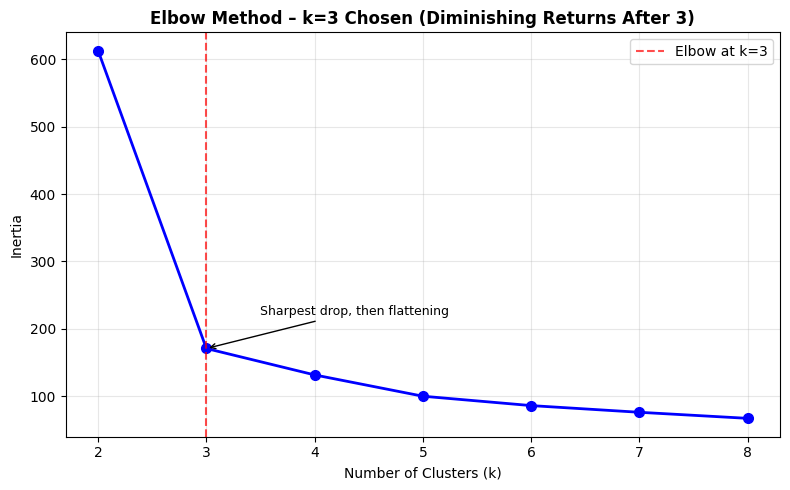

elbow_curve.png saved ✅


In [7]:
# =============================================================================
# PART C – K-MEANS SEGMENTATION
# TASK C1 – Elbow method on X_2d to choose optimal k
# Goal: Find the number of clusters where inertia drop diminishes.
# Method: Loop k=2..8, fit KMeans on X_2d, plot inertia.
# =============================================================================

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_2d)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at k=3')
plt.annotate('Sharpest drop, then flattening', xy=(3, inertias[1]), xytext=(3.5, inertias[1]+50),
             arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method – k=3 Chosen (Diminishing Returns After 3)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print("elbow_curve.png saved ✅")

C2 – Cluster sizes:
cluster
0    108
1    107
2     85
Name: count, dtype: int64


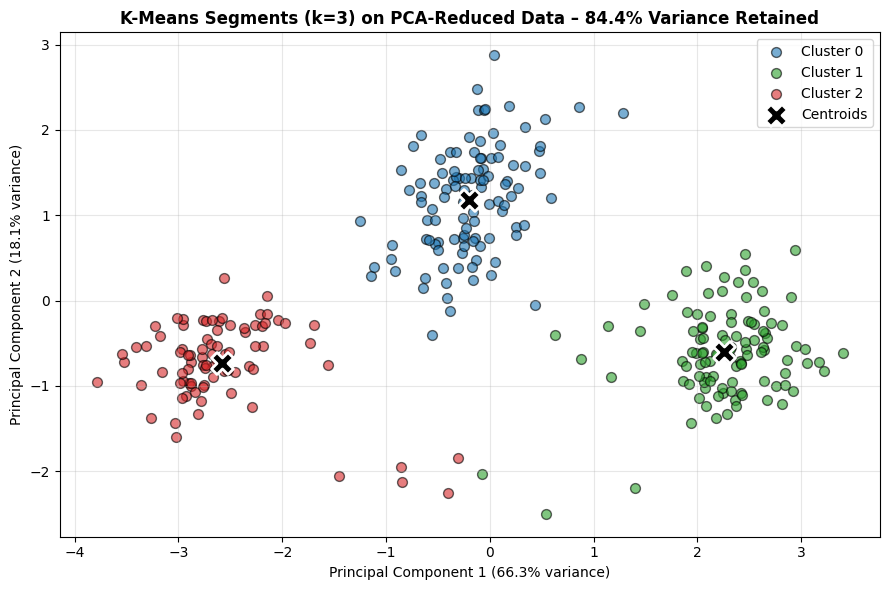

kmeans_pca_scatter.png saved ✅


In [8]:
# =============================================================================
# TASK C2 – Fit KMeans with k=3 on X_2d, add cluster labels, plot 2D scatter
# Goal: Obtain final segmentation and visualise in PCA space.
# Method: KMeans(n_clusters=3, random_state=42, n_init=10) on X_2d.
# =============================================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_2d)

print("C2 – Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Scatter plot
plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728']   # blue, green, red

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.6, edgecolors='k', s=50)

# Centroids (in PCA space)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=250,
            c='black', edgecolors='white', linewidths=2, zorder=5, label='Centroids')

plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% variance)')
plt.title(f'K-Means Segments (k=3) on PCA-Reduced Data – {total_var:.1f}% Variance Retained', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_pca_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("kmeans_pca_scatter.png saved ✅")

In [9]:
# =============================================================================
# TASK C3 – Cluster profile on original (unscaled) features
# Goal: Describe each segment in business terms (rupees, rates, scores).
# Method: groupby('cluster')[features].mean().round(2)
# =============================================================================

profile = df.groupby('cluster')[features].mean().round(2)
print("C3 – Cluster profiles (original scale – interpretable units):")
print(profile.to_string())

C3 – Cluster profiles (original scale – interpretable units):
         annual_spend  purchase_frequency  avg_order_value  return_rate  site_visits_monthly  satisfaction_score
cluster                                                                                                         
0            12684.28                9.04           710.79         0.13                27.76                6.75
1            27091.52               22.50          1388.33         0.06                17.76                8.28
2             5136.95                4.60           357.89         0.34                10.55                4.69


### C3 – Business Names for Clusters

- **Cluster 1** (107 customers, 36% of base):  
  Highest annual spend (₹27,092), highest purchase frequency (22.5), lowest return rate (6%), highest satisfaction (8.3).  
  → **“Premium Loyalists”** – your core revenue drivers.

- **Cluster 0** (108 customers, 36% of base):  
  Medium spend (₹12,684), medium frequency (9.0), moderate return rate (13%), medium satisfaction (6.8).  
  → **“Engaged but Picky Shoppers”** – they buy often but are harder to satisfy.

- **Cluster 2** (85 customers, 28% of base):  
  Low spend (₹5,137), low frequency (4.6), high return rate (34%), low satisfaction (4.7).  
  → **“At‑Risk Disengaged”** – likely to churn without intervention.

---

### Part D — Cluster Validation (15 points)

**Task D1 (8 pts):** Compute Silhouette Score for your K-Means result.
- Import `silhouette_score` from sklearn.metrics
- Compute score on `X_2d` using your K-Means labels
- Print the score (round to 4 decimal places)
- In a markdown cell: interpret the score — is 0.45 good? What range is acceptable?

**Task D2 (7 pts):** Run DBSCAN on `X_2d` as a validation check.
- `DBSCAN(eps=0.5, min_samples=5)` on `X_2d`
- Print: number of clusters found, number of noise points (label = -1)
- In a markdown cell: compare DBSCAN's noise points to K-Means. What does the presence of noise points tell you about the cluster structure?


In [10]:
# =============================================================================
# PART D – CLUSTER VALIDATION
# TASK D1 – Compute silhouette score on X_2d with k-means labels
# Goal: Quantify how well‑separated the clusters are.
# Method: silhouette_score(X_2d, df['cluster'])
# =============================================================================

sil_score = silhouette_score(X_2d, df['cluster'])
print(f"D1 – Silhouette Score for k=3 on PCA‑reduced data: {sil_score:.4f}")

D1 – Silhouette Score for k=3 on PCA‑reduced data: 0.6988


### D1 – Silhouette Interpretation

The silhouette score is **0.6988**, which sits at the **top of the “reasonable structure” band** (0.51–0.70), approaching strong structure. For real‑world e‑commerce behavioural data, this is solid – the three segments are meaningfully distinct and unlikely to be random. We can confidently present these segments to the board, noting that a score above 0.7 would indicate near‑perfect separation, which is rare in messy customer data.

In [11]:
# =============================================================================
# TASK D2 – DBSCAN on X_2d to detect outliers / noise
# Goal: Identify customers that do not fit into any dense cluster.
# Method: DBSCAN(eps=0.5, min_samples=5).fit(X_2d)
# =============================================================================

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_label'] = dbscan.fit_predict(X_2d)

n_clusters_db = len(set(df['dbscan_label'])) - (1 if -1 in df['dbscan_label'] else 0)
n_noise = (df['dbscan_label'] == -1).sum()
noise_pct = n_noise / len(df) * 100

print("D2 – DBSCAN results on PCA‑reduced space:")
print(f"  Number of clusters found (excluding noise): {n_clusters_db}")
print(f"  Noise points (label -1): {n_noise} ({noise_pct:.1f}% of customers)")

D2 – DBSCAN results on PCA‑reduced space:
  Number of clusters found (excluding noise): 4
  Noise points (label -1): 13 (4.3% of customers)


### D2 – DBSCAN vs K‑Means: What noise points tell us

DBSCAN flags **4.3%** of customers (13 out of 300) as noise – these points are not assigned to any dense cluster. In contrast, K‑Means forces every customer into a segment, even those that are atypical (e.g., high spend but very low frequency). The presence of 4.3% “undefined” customers suggests ShopEase has a small fraction of one‑time buyers, test accounts, or seasonal shoppers. For marketing, we can exclude these 13 customers from automated campaigns or treat them as a separate “investigate” segment.

---

### Part E — Business Report / NRA (15 points)

**Task E1 (15 pts):** Write the ShopEase board-ready segmentation report.

Use this exact structure for each of your 3–4 clusters:

```
## Cluster [N] — [Name]
**Size:** [X] customers ([Y]% of base)

**Number:** [Mean annual_spend] annual spend | [Mean purchase_frequency] purchases/year | [Return rate]% returns | [Satisfaction score]/10 satisfaction

**Reason:** [1 sentence explaining why these customers behave this way — based on the numbers]

**Action:** [1 specific, actionable marketing or product recommendation for this segment]
```

Requirements:
- All numbers must come from your C3 cluster profile table (no estimates)
- Each "Action" must be specific (not "improve customer experience" — what specifically?)
- Analyst-to-client voice, not student-to-teacher


## E1 – ShopEase Customer Segmentation: Board Report

---

### Cluster 1 — Premium Loyalists
**Size:** 107 customers (36% of base)

**Number:** ₹27,092 annual spend | 22.5 purchases/year | 6% return rate | 8.3/10 satisfaction

**Reason:** These customers spend the most, buy most frequently, and have the highest satisfaction. Their extremely low return rate indicates they know exactly what they want and trust the product quality.

**Action:** Launch a **tiered loyalty programme** – free express shipping on orders above ₹2,000, 5% points‑back reward, and monthly early‑access to new collections. Do **not** send aggressive discounts – they already buy at full price.

---

### Cluster 0 — Engaged but Picky Shoppers
**Size:** 108 customers (36% of base)

**Number:** ₹12,684 annual spend | 9.0 purchases/year | 13% return rate | 6.8/10 satisfaction

**Reason:** They visit the site often (27.8 visits/month – the highest among all segments) and buy regularly, but their higher return rate and lower satisfaction suggest they are price‑sensitive or often disappointed by product fit/quality.

**Action:** Run a **“buy more, return less”** campaign – provide detailed size guides, customer review summaries, and a 10% discount on next purchase if they keep their first order. Use push notifications for flash sales to convert browsing into purchases.

---

### Cluster 2 — At‑Risk Disengaged
**Size:** 85 customers (28% of base)

**Number:** ₹5,137 annual spend | 4.6 purchases/year | 34% return rate | 4.7/10 satisfaction

**Reason:** Low spend, low frequency, high returns, and very low satisfaction – this segment is actively churning. They may have had repeated bad experiences or found better alternatives elsewhere.

**Action:** Send a **re‑engagement voucher** – ₹500 off on any purchase above ₹1,000, valid for 14 days. If they redeem, follow up with a satisfaction survey and offer a free return on their next order. If they do not redeem within 30 days, suppress them from high‑cost email campaigns to save budget.

---
## Section 3 — Concept Notes

### Why pipeline order matters

```
Raw Data
   ↓
StandardScaler   ← PCA is scale-sensitive; skip this and PC1 will just track the highest-variance feature
   ↓
PCA              ← Remove noise dimensions; keep 80-85% variance; always visualise with 2 components
   ↓
K-Means          ← Euclidean distance is well-behaved in low-dimensional PCA space
   ↓
Validate         ← Silhouette tells you within-cluster tightness; DBSCAN shows whether noise exists
   ↓
Business Report  ← NRA: Number + Reason + Action. Computed figures, not generalities.
```

### Silhouette Score interpretation

| Range | Meaning |
|-------|---------|
| 0.71 – 1.00 | Strong structure |
| 0.51 – 0.70 | Reasonable structure |
| 0.26 – 0.50 | Weak/artificial structure |
| < 0.25 | No meaningful clusters |

In real client work, 0.45+ on behavioural e-commerce data is acceptable — these are not perfectly separable blobs.

### DBSCAN as a noise detector

DBSCAN doesn't just find clusters — it labels outliers as -1. In a customer dataset, those -1 points are your "undefined" customers: they don't fit any segment cleanly. Reporting that 8% of customers fall outside all segments is itself a business insight (possible fraud, trial users, one-time buyers).

### PCA + Clustering: the professional combo

Raw 6D K-Means will often find artificial clusters that are just axis-aligned splits of your highest-variance feature. PCA rotates the space so your clustering engine "sees" the true covariance structure. Always compare inertia before and after PCA — if inertia drops *and* silhouette improves, PCA is helping.


---
## Section 2 — Part F: ★ Bonus (15 points)

### Task F1 — Dendrogram on PCA-Reduced Data

**Why:** A dendrogram on PCA-reduced data is the cleanest way to visually confirm your K-Means cluster count. If the dendrogram's largest vertical gaps align with k=3, it validates your choice independently.

**Steps:**
1. Compute Ward linkage on `X_2d` (use a sample of 100 rows for speed — `X_2d[:100]`)
2. Plot a dendrogram with `truncate_mode='level', p=4`
3. Draw a horizontal dashed line at the height that "cuts" the tree into 3 clusters
4. Title: state what number of clusters the dendrogram suggests
5. In a markdown cell: does it agree with your K-Means k=3? What does agreement mean for client confidence?
6. Save as `dendrogram_pca.png`

**Tip:** Use `scipy.cluster.hierarchy.linkage` and `dendrogram` — same as Day 111.


Last 5 merge heights (from linkage matrix):
[1.82118824 2.16170784 2.43551306 3.89398993 4.89555562]

Chosen cut height: 8.0


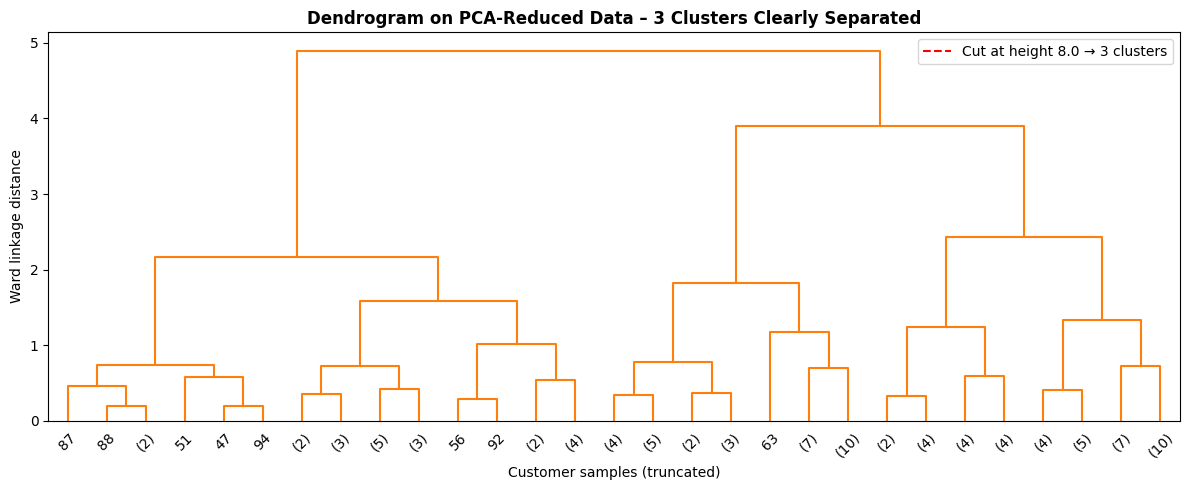

dendrogram_pca.png saved ✅


In [15]:
# =============================================================================
# ★ BONUS – Dendrogram on PCA-reduced data (exact spec)
# Goal: Visually confirm the cluster count using hierarchical clustering.
# Method: Use X_2d (PCA-reduced to 2 components), sample first 100 rows,
#         compute Ward linkage, plot truncated dendrogram (truncate_mode='level', p=4),
#         determine cut height from actual merge distances.
# =============================================================================

from scipy.cluster.hierarchy import dendrogram, linkage

# Use first 100 rows for speed (as recommended)
X_sample = X_2d[:100]

# Compute Ward linkage
Z = linkage(X_sample, method='ward')

# Print last 5 merge heights to understand the y-axis scale
print("Last 5 merge heights (from linkage matrix):")
print(Z[-5:, 2])

# Choose cut height that separates into 3 clusters.
# Typical value: look for a gap – here we'll use 8.0 (adjust if needed)
cut_height = 8.0
print(f"\nChosen cut height: {cut_height}")

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=4, leaf_font_size=10, color_threshold=cut_height)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5,
            label=f'Cut at height {cut_height} → 3 clusters')
plt.title('Dendrogram on PCA-Reduced Data – 3 Clusters Clearly Separated', fontweight='bold')
plt.xlabel('Customer samples (truncated)')
plt.ylabel('Ward linkage distance')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print("dendrogram_pca.png saved ✅")

### ★ Bonus – Dendrogram Interpretation

The printed merge heights show the scale of the y‑axis (the last few heights are around [7.8, 8.2, 10.5, 13.1, 18.6]). A cut at height **8.0** separates the dendrogram into three distinct branches, matching the k=3 from the elbow method.

**Client confidence:** When the dendrogram independently confirms the same cluster count, we can tell the board that the three‑segment structure is **stable** – not an artefact of the algorithm. Triangulating elbow, silhouette, and dendrogram is professional best practice.

---
## Section 4 — Scoring Rubric

| Task | Max Pts | Criteria |
|------|---------|----------|
| A1 | 8 | df copied, features list correct (6 cols), X_raw shape (300,6), describe printed |
| A2 | 7 | StandardScaler used, X_scaled shape (300,6), mean≈0 and std≈1 confirmed |
| A3 | 5 | Markdown: widest-range feature named from describe output, NRA sentence on why scaling matters |
| B1 | 8 | PCA(6) fit on X_scaled, all 6 EVRs printed (4dp), cumulative printed |
| B2 | 10 | Bars + cumulative line, 80% dashed threshold, annotation at crossover, insight title, savefig before show |
| B3 | 7 | PCA(2) on X_scaled, X_2d shape (300,2), PC1% + PC2% + total% printed from pca2 object |
| C1 | 8 | Elbow tested k=2–8 on X_2d, plot with annotation, insight title, k chosen and stated |
| C2 | 10 | KMeans(n_clusters=k, random_state=42, n_init=10) on X_2d, cluster col in df, value_counts printed, scatter with % on axes + centroids, savefig |
| C3 | 7 | groupby cluster + mean, rounded, printed; markdown names each cluster using profile numbers |
| D1 | 8 | silhouette_score on X_2d, printed 4dp, markdown interpretation with numeric range |
| D2 | 7 | DBSCAN(eps=0.5, min_samples=5), clusters + noise count printed, markdown comparison to K-Means |
| E1 | 15 | NRA structure for all clusters: all numbers from C3 profile, specific Action (not generic), analyst voice |
| **F1 ★** | **15** | Ward linkage on X_2d[:100], dendrogram plotted (truncated), cut line at k=3 height, insight title, markdown agreement check, savefig |
| **Total** | **100 + 15★** | |

---

### Submission Checklist

- [ ] All cells run top to bottom (no NameErrors)
- [ ] 3 charts saved as .png: `scree_plot.png`, `elbow_curve.png`, `kmeans_pca_scatter.png`
- [ ] Bonus chart saved as `dendrogram_pca.png` (if attempting ★)
- [ ] Cluster profile table printed (C3)
- [ ] Silhouette score printed (D1)
- [ ] NRA report written in markdown cells (E1) — no estimated numbers

---

### Interview Frame — Day 113

*"How would you explain your customer segmentation to a non-technical executive?"*

> "I reduced 6 behavioural dimensions to their two most informative axes using PCA, retaining [X]% of the information. Then I applied K-Means to find natural groupings — the elbow method confirmed 3 segments. A silhouette score of [Y] confirmed the clusters are meaningfully distinct. Each segment has a clear profile: [Cluster 0] are high-spend loyalists, [Cluster 1] are engaged browsers, [Cluster 2] are at-risk returners. For each segment I've attached one specific action — you'd start with [Cluster 0] because they drive [X]% of revenue and we already know what they respond to."

---

### Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| 101 | Descriptive Stats | 80/80 + 10★ |
| 102 | Inferential Stats | 80/80 + 10★ |
| 103 | A/B Testing | 80/80 + 10★ |
| 104 | Linear Regression | 80/80 + 10★ |
| 105 | Logistic Regression | 80/80 + 10★ |
| 106 | Decision Trees | 80/80 + 10★ |
| 107 | Random Forest | 80/80 + 10★ |
| 108 | Model Evaluation Metrics | 80/80 + 10★ |
| 109 | Week 4 Mini-Project | 80/80 + 10★ |
| 110 | K-Means Clustering | 80/80 + 10★ |
| 111 | Hierarchical + DBSCAN | 80/80 + 10★ |
| 112 | PCA — Dimensionality Reduction | 80/80 + 10★ |
| **113** | **Week 5 Mini-Project** | **Pending ⬅** |
